In [7]:
import pandas as pd


In [3]:
import os
print(os.getcwd())
print(os.listdir())

C:\Users\KIIT\Desktop\Loan appoval prediction
['.ipynb_checkpoints', 'LoanApprovalPrediction.csv', 'Untitled.ipynb']


In [8]:
df = pd.read_csv("LoanApprovalPrediction.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [11]:
df.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)

df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

C:\Users\KIIT\AppData\Local\Temp\ipykernel_18904\2531043719.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
C:\Users\KIIT\AppData\Local\Temp\ipykernel_18904\2531043719.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a

In [13]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [14]:
df.drop('Loan_ID', axis=1, inplace=True)

In [15]:
df.select_dtypes(include='object').columns

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area',
       'Loan_Status'],
      dtype='object')

In [16]:
df['Gender'] = df['Gender'].map({'Male':1, 'Female': 0})
df['Married'] = df['Married'].map({'Yes':1, 'No': 0})
df['Education'] = df['Education'].map({'Graduate':1, 'Not Graduate':0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1, 'No':0})
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

In [17]:
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True)

In [18]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,1,0,5849,0.0,127.0,360.0,1.0,1,False,True
1,1,1,1.0,1,0,4583,1508.0,128.0,360.0,1.0,0,False,False
2,1,1,0.0,1,1,3000,0.0,66.0,360.0,1.0,1,False,True
3,1,1,0.0,0,0,2583,2358.0,120.0,360.0,1.0,1,False,True
4,1,0,0.0,1,0,6000,0.0,141.0,360.0,1.0,1,False,True


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   598 non-null    int64  
 1   Married                  598 non-null    int64  
 2   Dependents               598 non-null    float64
 3   Education                598 non-null    int64  
 4   Self_Employed            598 non-null    int64  
 5   ApplicantIncome          598 non-null    int64  
 6   CoapplicantIncome        598 non-null    float64
 7   LoanAmount               598 non-null    float64
 8   Loan_Amount_Term         598 non-null    float64
 9   Credit_History           598 non-null    float64
 10  Loan_Status              598 non-null    int64  
 11  Property_Area_Semiurban  598 non-null    bool   
 12  Property_Area_Urban      598 non-null    bool   
dtypes: bool(2), float64(5), int64(6)
memory usage: 52.7 KB


In [20]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   598 non-null    int64  
 1   Married                  598 non-null    int64  
 2   Dependents               598 non-null    float64
 3   Education                598 non-null    int64  
 4   Self_Employed            598 non-null    int64  
 5   ApplicantIncome          598 non-null    int64  
 6   CoapplicantIncome        598 non-null    float64
 7   LoanAmount               598 non-null    float64
 8   Loan_Amount_Term         598 non-null    float64
 9   Credit_History           598 non-null    float64
 10  Loan_Status              598 non-null    int64  
 11  Property_Area_Semiurban  598 non-null    bool   
 12  Property_Area_Urban      598 non-null    bool   
dtypes: bool(2), float64(5), int64(6)
memory usage: 52.7 KB


In [24]:
print(X_train.shape)
print(X_test.shape)

(478, 12)
(120, 12)


In [25]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy)

Accuracy = 0.825


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[15 20]
 [ 1 84]]


In [29]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.43      0.59        35
           1       0.81      0.99      0.89        85

    accuracy                           0.82       120
   macro avg       0.87      0.71      0.74       120
weighted avg       0.85      0.82      0.80       120



In [30]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.6916666666666667


In [31]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(importance.sort_values(by='Coefficient', ascending=False))

                    Feature  Coefficient
9            Credit_History     3.207900
10  Property_Area_Semiurban     0.854460
1                   Married     0.482078
11      Property_Area_Urban     0.390533
3                 Education     0.293217
5           ApplicantIncome    -0.000014
6         CoapplicantIncome    -0.000042
7                LoanAmount    -0.001477
2                Dependents    -0.001523
8          Loan_Amount_Term    -0.003436
4             Self_Employed    -0.155388
0                    Gender    -0.192522


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
original_df = pd.read_csv("LoanApprovalPrediction.csv")

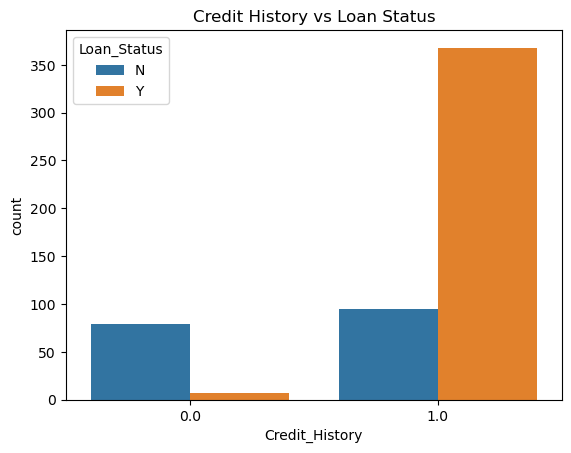

In [35]:
sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=original_df
)

plt.title("Credit History vs Loan Status")
plt.show()

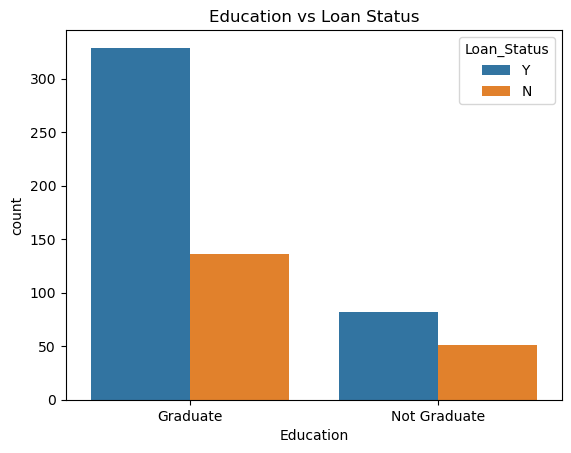

In [36]:
sns.countplot(
    x='Education',
    hue='Loan_Status',
    data=original_df
)

plt.title("Education vs Loan Status")
plt.show()

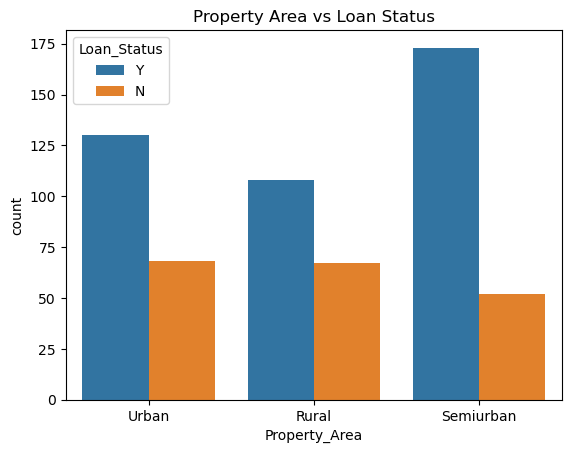

In [37]:
sns.countplot(
    x='Property_Area',
    hue='Loan_Status',
    data=original_df
)

plt.title("Property Area vs Loan Status")
plt.show()

In [38]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
9,Credit_History,3.207900
10,Property_Area_Semiurban,0.854460
1,Married,0.482078
11,Property_Area_Urban,0.390533
3,Education,0.293217
5,ApplicantIncome,-0.000014
6,CoapplicantIncome,-0.000042
7,LoanAmount,-0.001477
2,Dependents,-0.001523
8,Loan_Amount_Term,-0.003436


In [39]:
y_pred = model.predict(X_test)

In [41]:
new_data = [[
    1,  # Gender
    1,  # Married
    1,  # Dependents
    1,  # Education
    0,  # Self_Employed
    5000,
    2000,
    120,
    360,
    0,  # Credit_History
    1,  # Semiurban
    0   # Urban
]]

prediction = model.predict(new_data)

print(prediction)

[0]


c:\Users\KIIT\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [42]:
import pickle

with open("loan_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model Saved Successfully!")

Model Saved Successfully!


In [43]:
import os
print(os.listdir())

['.ipynb_checkpoints', 'LoanApprovalPrediction.csv', 'loan_model.pkl', 'Untitled.ipynb']
